# Phase 1 QC & Phase 2: Differential Expression Analysis

**Phase 1 (EDA):** Quick exploratory analysis of the pre-filtered TCGA-BRCA dataset — PCA, sample correlation, library sizes.

**Phase 2 (DEA):** Differential expression with PyDESeq2 — each subtype vs Normal, volcano plots, and top-DEG heatmap.

## Step 1: Query GDC and Download TCGA-BRCA Expression Batches
Fetch file metadata from GDC, split file IDs into chunks, and download tar.gz batches.

In [1]:
import requests
import json

BASE_URL = "https://api.gdc.cancer.gov"
download_url = f"{BASE_URL}/data"

filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "files.data_type", "value": "Gene Expression Quantification"}},
    ]
}

params = {
    "filters": json.dumps(filters),
    "fields": "file_id,file_name,cases.samples.submitter_id",
    "format": "JSON",
    "size": 2000
}

response = requests.get(f"{BASE_URL}/files", params=params)
response.raise_for_status()
data = response.json()["data"]["hits"]

file_ids = [f["file_id"] for f in data]

print(f"Total files: {len(file_ids)}")

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 100

for i, batch in enumerate(chunks(file_ids, batch_size)):
    print(f"Downloading batch {i}")

    response = requests.post(download_url, json={"ids": batch}, stream=True)
    response.raise_for_status()

    with open(f"tcga_batch_{i}.tar.gz", "wb") as f:
        for chunk in response.iter_content(chunk_size=1024*1024):
            f.write(chunk)

print("Download done")

Total files: 1231
Download done


## Step 2: Extract Batches and Build Raw Expression Matrix
Extract each tar archive, read per-sample TSV files, map UUID to sample ID, and concatenate into one expression matrix.

In [2]:
import pandas as pd
import numpy as np
import os
import tarfile

# FIX: map using UUID only
file_id_to_barcode = {
    item["file_name"].split(".")[0]: item["cases"][0]["samples"][0]["submitter_id"]
    for item in data
}

dfs = []
num_batches = 13

for i in range(num_batches):
    batch_file = f'./tcga_batch_{i}.tar.gz'
    extract_path = f'./batch_{i}'

    if not os.path.exists(batch_file):
        print(f"Missing: {batch_file}")
        continue

    if not os.path.exists(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        with tarfile.open(batch_file, 'r:gz') as tar:
            tar.extractall(extract_path)

    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith(".tsv"):
                file_path = os.path.join(root, file)

                try:
                    df = pd.read_csv(file_path, sep='\t', skiprows=1)
                    df = df[['gene_name', 'unstranded']]
                    df = df.set_index('gene_name')

                    # FIX: extract UUID
                    file_id = file.split(".")[0]
                    sample_name = file_id_to_barcode.get(file_id)

                    if sample_name is None:
                        print("Missing mapping:", file)
                        continue

                    df.columns = [sample_name]
                    dfs.append(df)

                except Exception as e:
                    print(f"Error: {file_path}")

# CONCAT
exp_data = pd.concat(dfs, axis=1)

# IMPORTANT: collapse duplicates
exp_data = exp_data.groupby(exp_data.columns, axis=1).mean()

print("Final shape:", exp_data.shape)
print("Unique samples:", len(exp_data.columns))
print(exp_data.columns[:5])

C:\Users\AUB\AppData\Local\Temp\ipykernel_20384\3713996661.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
C:\Users\AUB\AppData\Local\Temp\ipykernel_20384\3713996661.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
C:\Users\AUB\AppData\Local\Temp\ipykernel_20384\3713996661.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
C:\Users\AUB\AppData\Local\Temp\ipykernel_20384\3713996661.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. U

Final shape: (60664, 1226)
Unique samples: 1226
Index(['TCGA-3C-AAAU-01A', 'TCGA-3C-AALI-01A', 'TCGA-3C-AALJ-01A',
       'TCGA-3C-AALK-01A', 'TCGA-4H-AAAK-01A'],
      dtype='object')


## Step 3: Load Clinical Labels and Check Sample Overlap
Load the Shamir annotation sheet, standardize sample IDs, and verify overlap with expression samples.

In [3]:
import pandas as pd

shamir = pd.read_excel("shamir.xlsx", sheet_name=1)

print(shamir.head())
print(shamir.columns)
shamir['sample_fixed'] = shamir['Sample ID'].str.strip() + "A"
exp_samples = exp_data.columns.str.strip()
overlap = set(exp_samples).intersection(set(shamir['sample_fixed']))

print("Overlap count:", len(overlap))
print("Expression samples:", len(exp_samples))
print("Shamir samples:", shamir['sample_fixed'].nunique())

         Sample ID  Cluster ID Age (Median) ER Status PR Status Her2 Status  \
0  TCGA-BH-A0C7-01           1           48  Positive  Negative    Positive   
1  TCGA-A8-A06N-01           1           66  Positive  Negative    Negative   
2  TCGA-D8-A1XU-01           1           56  Positive  Positive    Negative   
3  TCGA-AR-A0TV-01           1           66  Positive  Positive    Negative   
4  TCGA-D8-A1XV-01           1           84  Positive  Positive    Negative   

  PAM50 Pathologic stage              Histological type  
0  LumB         Stage II  Infiltrating Ductal Carcinoma  
1  LumB        Stage III  Infiltrating Ductal Carcinoma  
2  LumA          Stage I  Infiltrating Ductal Carcinoma  
3  LumB         Stage II  Infiltrating Ductal Carcinoma  
4  LumA         Stage II             Mucinous Carcinoma  
Index(['Sample ID', 'Cluster ID', 'Age (Median)', 'ER Status', 'PR Status',
       'Her2 Status', 'PAM50', 'Pathologic stage', 'Histological type'],
      dtype='object')
Overla

## Step 4: Build PAM50 Subtype Annotation Table and Align Expression Columns
Create sample metadata with subtype labels and reorder expression columns to match metadata index.

In [4]:
metadata = pd.DataFrame({
    "sample_id": exp_data.columns
})

metadata = metadata.merge(
    shamir[['sample_fixed', 'PAM50']],
    left_on='sample_id',
    right_on='sample_fixed',
    how='inner'   # important → only keep matches
)

metadata = metadata.drop(columns=['sample_fixed'])
metadata = metadata.rename(columns={'PAM50': 'subtype'})

metadata = metadata.set_index('sample_id')

# align expression data
exp_data = exp_data[metadata.index]

print("Final samples:", exp_data.shape[1])
print(metadata['subtype'].value_counts())

Final samples: 1118
subtype
LumA      528
LumB      198
Basal     181
Normal    134
Her2       77
Name: count, dtype: int64


## Step 5: Apply Basic Gene Filtering and Save Outputs
Remove invalid gene rows, keep genes expressed in at least 2 samples, and save filtered inputs for downstream differential expression analysis.

In [5]:
# Remove genes with missing names
exp_data = exp_data[exp_data.index.notna()]

# Basic prevalence filter: keep genes expressed in at least 2 samples
keep = (exp_data > 10).sum(axis=1) >= 2
exp_data_filtered = exp_data[keep]

# Save filtered matrix + metadata for DEA phase
exp_data_filtered.to_pickle("exp_data_filtered.pkl")
metadata.to_pickle("metadata.pkl")

print("After basic filtering (>=2 samples with count > 10):", exp_data_filtered.shape)
print("Saved filtered matrix to exp_data_filtered.pkl")
print("Saved metadata to metadata.pkl")

After basic filtering (>=2 samples with count > 10): (41866, 1118)
Saved filtered matrix to exp_data_filtered.pkl
Saved metadata to metadata.pkl


## Step 6: Quick Distribution Check on Filtered Data
Plot a subset of filtered samples with log-scaled boxplots for a fast sanity check of count distributions.

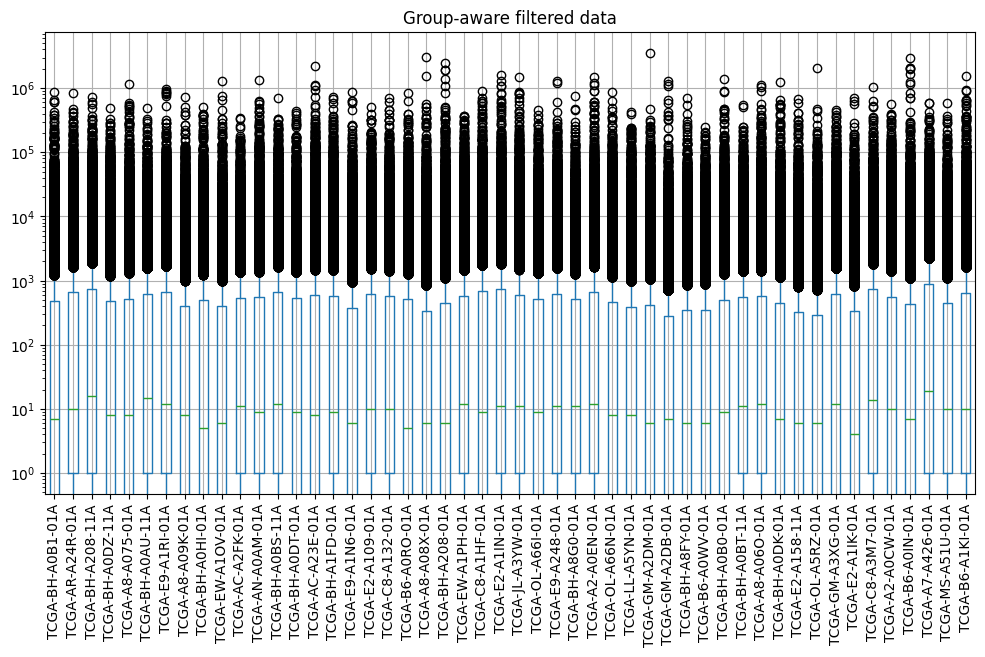

In [2]:
subset = exp_data_filtered.sample(50, axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
subset.boxplot()

plt.yscale('log')
plt.title('Group-aware filtered data')
plt.xticks(rotation=90)

plt.show()

## Step 7: PCA Visualization by Subtype
Run PCA on transformed expression data and visualize clustering structure by subtype.

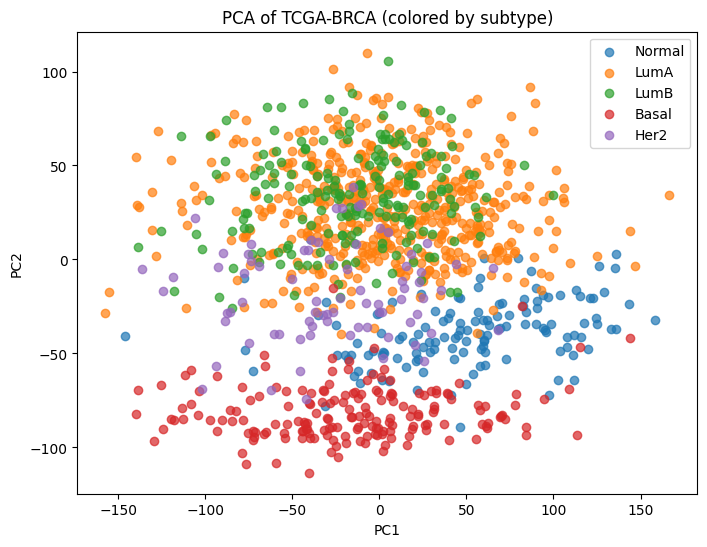

In [5]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reload saved inputs so this cell works even after a kernel restart
exp_data_filtered = pd.read_pickle("exp_data_filtered.pkl")
metadata = pd.read_pickle("metadata.pkl")
metadata = metadata.loc[exp_data_filtered.columns]

# transpose: samples × genes
X = exp_data_filtered.T

# log transform (IMPORTANT for PCA)
X_log = np.log1p(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_log)

# plot
plt.figure(figsize=(8, 6))

for subtype in metadata["subtype"].unique():
    idx = metadata["subtype"] == subtype
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=subtype, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TCGA-BRCA (colored by subtype)")
plt.legend()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import warnings, os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Load filtered data generated in Step 5
exp_raw = pd.read_pickle("exp_data_filtered.pkl")
metadata  = pd.read_pickle("metadata.pkl")

# Deduplicate gene names — keep the row with the highest mean expression
n_before = exp_raw.shape[0]
exp_raw["_mean"] = exp_raw.mean(axis=1, numeric_only=True)
exp = (exp_raw
       .reset_index()
       .sort_values("_mean", ascending=False)
       .drop_duplicates(subset="gene_name", keep="first")
       .drop(columns=["_mean"])
       .set_index("gene_name"))
n_after = exp.shape[0]

print(f"Expression matrix : {n_before:,} → {n_after:,} genes after deduplication ({n_before - n_after:,} removed)")
print(f"                    {exp.shape[1]} samples")
assert exp.index.is_unique, "Gene index still has duplicates!"

# Consistent palette used throughout all notebooks
SUBTYPE_COLORS = {
    "LumA": "#1f77b4", "LumB": "#ff7f0e",
    "Basal": "#d62728", "Her2": "#9467bd", "Normal": "#2ca02c",
}
SUBTYPE_ORDER = ["Basal", "Her2", "LumA", "LumB", "Normal"]

print(f"\nSubtype counts:\n{metadata['subtype'].value_counts().loc[SUBTYPE_ORDER]}")

Expression matrix : 41,866 → 41,556 genes after deduplication (310 removed)
                    1118 samples

Subtype counts:
subtype
Basal     181
Her2       77
LumA      528
LumB      198
Normal    134
Name: count, dtype: int64


---
## Phase 1 — Exploratory Data Analysis

### 1.1 Library Size Distribution

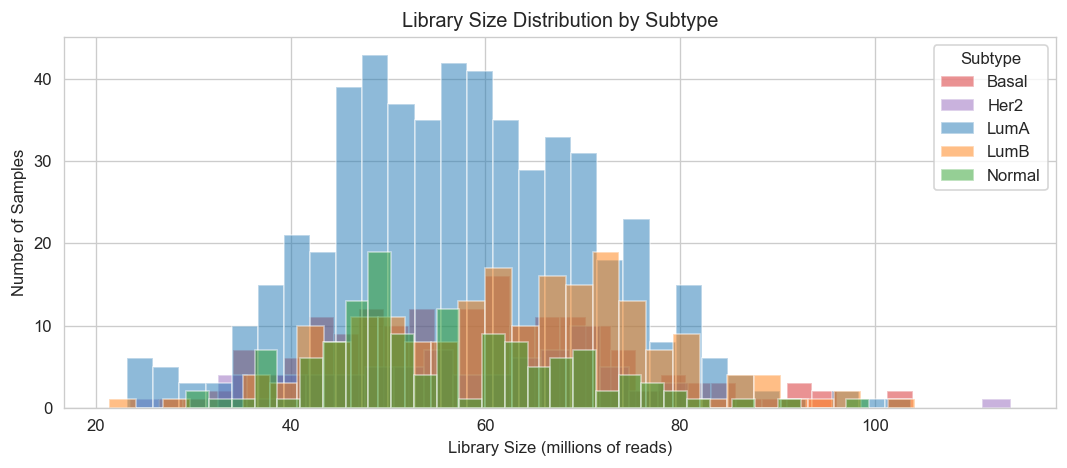

Range: 21.3M – 114.0M | Median: 58.1M


In [7]:
lib_sizes = exp.sum(axis=0)
lib_df = pd.DataFrame({"library_size": lib_sizes}).join(metadata)

fig, ax = plt.subplots(figsize=(9, 4))
for st in SUBTYPE_ORDER:
    vals = lib_df.loc[lib_df["subtype"] == st, "library_size"] / 1e6
    ax.hist(vals, bins=30, alpha=0.5, label=st, color=SUBTYPE_COLORS[st])
ax.set_xlabel("Library Size (millions of reads)")
ax.set_ylabel("Number of Samples")
ax.set_title("Library Size Distribution by Subtype")
ax.legend(title="Subtype")
plt.tight_layout()
plt.savefig("figures/library_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Range: {lib_sizes.min()/1e6:.1f}M – {lib_sizes.max()/1e6:.1f}M | Median: {lib_sizes.median()/1e6:.1f}M")

### 1.2 PCA — Subtype Clustering

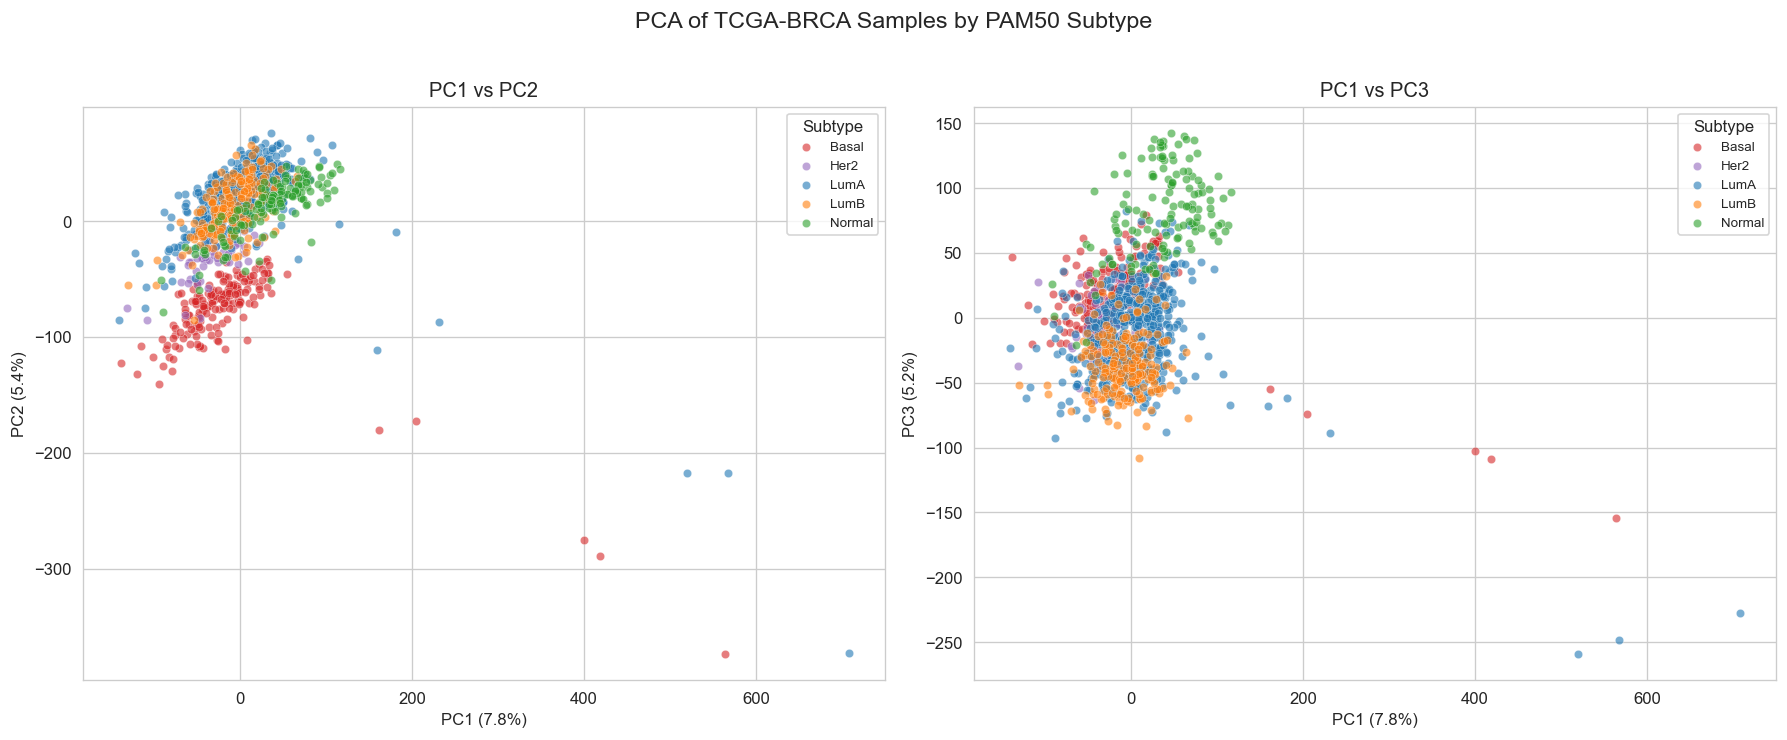

Cumulative variance (top 10 PCs): 33.4%


In [8]:
# log2-CPM for visualization only
cpm = exp.div(exp.sum(axis=0), axis=1) * 1e6
log2_cpm = np.log2(cpm + 1)

# PCA on standardized log2-CPM
X_scaled = StandardScaler().fit_transform(log2_cpm.T)  # samples × genes
pca = PCA(n_components=10).fit(X_scaled)
pcs = pca.transform(X_scaled)
var_pct = pca.explained_variance_ratio_ * 100

pc_df = pd.DataFrame(pcs[:, :3], columns=["PC1", "PC2", "PC3"], index=exp.columns).join(metadata)

# PC1 vs PC2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for st in SUBTYPE_ORDER:
    m = pc_df["subtype"] == st
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"],
                    c=SUBTYPE_COLORS[st], label=st, alpha=0.6, s=25, edgecolors="white", linewidths=0.3)
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC3"],
                    c=SUBTYPE_COLORS[st], label=st, alpha=0.6, s=25, edgecolors="white", linewidths=0.3)

axes[0].set_xlabel(f"PC1 ({var_pct[0]:.1f}%)"); axes[0].set_ylabel(f"PC2 ({var_pct[1]:.1f}%)")
axes[0].set_title("PC1 vs PC2"); axes[0].legend(title="Subtype", fontsize=8)
axes[1].set_xlabel(f"PC1 ({var_pct[0]:.1f}%)"); axes[1].set_ylabel(f"PC3 ({var_pct[2]:.1f}%)")
axes[1].set_title("PC1 vs PC3"); axes[1].legend(title="Subtype", fontsize=8)
plt.suptitle("PCA of TCGA-BRCA Samples by PAM50 Subtype", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/pca_subtypes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cumulative variance (top 10 PCs): {var_pct.sum():.1f}%")

### 1.3 Sample Correlation Heatmap

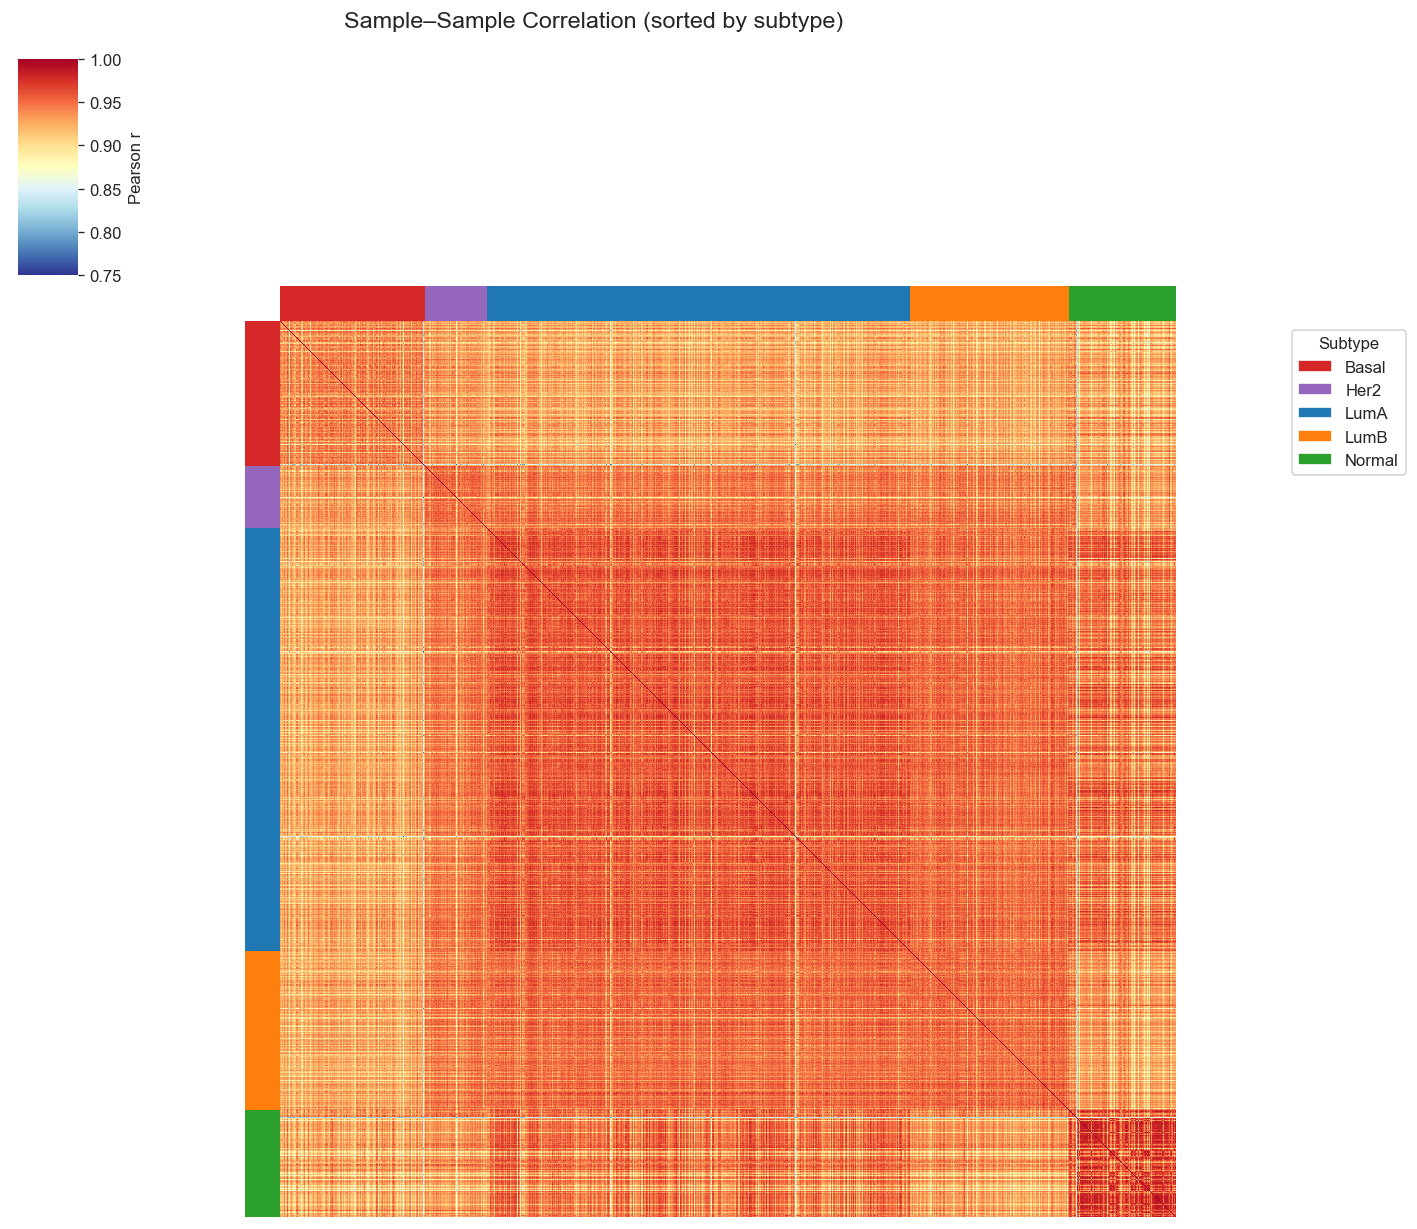

In [9]:
# Sort samples by subtype for block-diagonal structure
sorted_meta = metadata.loc[exp.columns].copy()
sorted_meta["subtype"] = pd.Categorical(sorted_meta["subtype"], categories=SUBTYPE_ORDER, ordered=True)
sorted_meta = sorted_meta.sort_values("subtype")
sorted_ids = sorted_meta.index.tolist()

corr = log2_cpm[sorted_ids].corr()
row_colors = sorted_meta["subtype"].map(SUBTYPE_COLORS)

g = sns.clustermap(
    corr, row_cluster=False, col_cluster=False,
    row_colors=row_colors.values, col_colors=row_colors.values,
    cmap="RdYlBu_r", vmin=0.75, vmax=1.0, figsize=(10, 10),
    xticklabels=False, yticklabels=False, cbar_kws={"label": "Pearson r"},
)
g.fig.suptitle("Sample–Sample Correlation (sorted by subtype)", y=1.02, fontsize=14)
legend_handles = [Patch(facecolor=SUBTYPE_COLORS[s], label=s) for s in SUBTYPE_ORDER]
g.ax_heatmap.legend(handles=legend_handles, title="Subtype", loc="upper left",
                    bbox_to_anchor=(1.12, 1.0), frameon=True)
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 2 — Differential Expression Analysis (PyDESeq2)

For each tumor subtype (Basal, Her2, LumA, LumB) we run a two-group comparison against Normal tissue using PyDESeq2. Significance thresholds: **|log₂FC| > 1.5** and **adjusted p-value < 0.01**.

In [10]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

LFC_THRESH = 1.5
PADJ_THRESH = 0.01

tumor_subtypes = ["Basal", "Her2", "LumA", "LumB"]
deg_results = {}  # subtype → DataFrame of DESeq2 results

for subtype in tumor_subtypes:
    print(f"\n{'='*60}")
    print(f"  Running DESeq2: {subtype} vs Normal")
    print(f"{'='*60}")

    # Subset to this subtype + Normal samples
    samples = metadata[metadata["subtype"].isin([subtype, "Normal"])].index
    counts_sub = exp[samples].T  # PyDESeq2 wants samples × genes
    counts_sub = counts_sub.astype(int)

    clinical_sub = metadata.loc[samples].copy()
    clinical_sub["condition"] = clinical_sub["subtype"].apply(lambda x: "Tumor" if x == subtype else "Normal")

    print(f"  Samples: {(clinical_sub['condition']=='Tumor').sum()} Tumor, "
          f"{(clinical_sub['condition']=='Normal').sum()} Normal")

    # Build DESeq2 dataset
    dds = DeseqDataSet(
        counts=counts_sub,
        metadata=clinical_sub,
        design="~condition",
        ref_level=["condition", "Normal"],
        quiet=True,
    )
    dds.deseq2()

    # Statistical testing
    stat_res = DeseqStats(dds, contrast=["condition", "Tumor", "Normal"], quiet=True)
    stat_res.summary()
    res_df = stat_res.results_df.copy()

    # Flag significant DEGs
    res_df["significant"] = (res_df["padj"] < PADJ_THRESH) & (res_df["log2FoldChange"].abs() > LFC_THRESH)
    n_up = ((res_df["significant"]) & (res_df["log2FoldChange"] > 0)).sum()
    n_down = ((res_df["significant"]) & (res_df["log2FoldChange"] < 0)).sum()

    print(f"  DEGs: {n_up} up, {n_down} down ({n_up + n_down} total)")

    deg_results[subtype] = res_df

print("\nAll comparisons complete.")


  Running DESeq2: Basal vs Normal
  Samples: 181 Tumor, 134 Normal
  DEGs: 3681 up, 2813 down (6494 total)

  Running DESeq2: Her2 vs Normal
  Samples: 77 Tumor, 134 Normal
  DEGs: 2686 up, 3562 down (6248 total)

  Running DESeq2: LumA vs Normal
  Samples: 528 Tumor, 134 Normal
  DEGs: 1736 up, 2705 down (4441 total)

  Running DESeq2: LumB vs Normal
  Samples: 198 Tumor, 134 Normal
  DEGs: 2450 up, 4103 down (6553 total)

All comparisons complete.


### 2.1 Volcano Plots

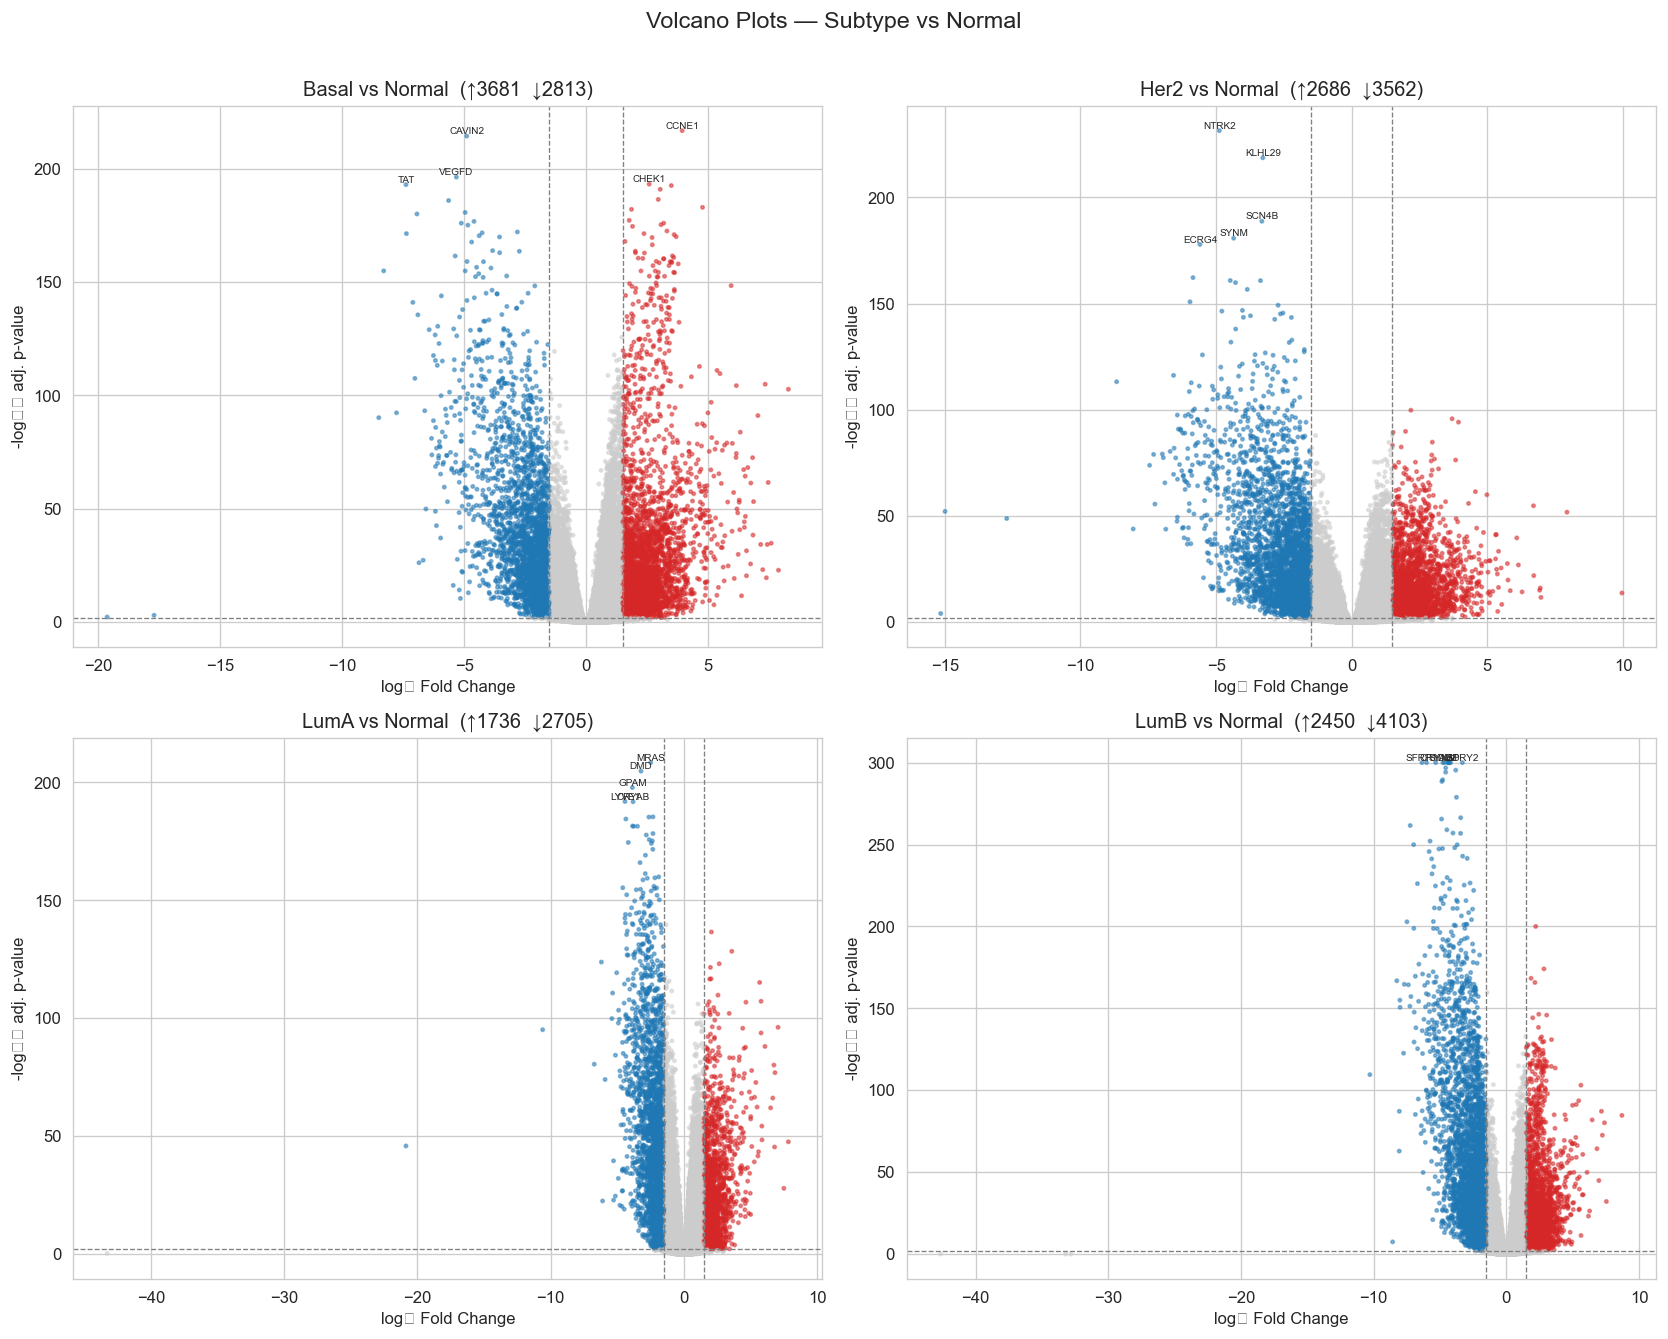

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, subtype in zip(axes.flatten(), tumor_subtypes):
    df = deg_results[subtype].dropna(subset=["padj", "log2FoldChange"]).copy()
    df["-log10padj"] = -np.log10(df["padj"].clip(lower=1e-300))

    # Color: grey=NS, blue=down, red=up
    colors = np.where(
        df["significant"] & (df["log2FoldChange"] > 0), "#d62728",
        np.where(df["significant"] & (df["log2FoldChange"] < 0), "#1f77b4", "#cccccc")
    )

    ax.scatter(df["log2FoldChange"], df["-log10padj"], c=colors, s=4, alpha=0.5)
    ax.axhline(-np.log10(PADJ_THRESH), color="grey", ls="--", lw=0.8)
    ax.axvline(-LFC_THRESH, color="grey", ls="--", lw=0.8)
    ax.axvline(LFC_THRESH, color="grey", ls="--", lw=0.8)

    n_up = ((df["significant"]) & (df["log2FoldChange"] > 0)).sum()
    n_down = ((df["significant"]) & (df["log2FoldChange"] < 0)).sum()
    ax.set_title(f"{subtype} vs Normal  (↑{n_up}  ↓{n_down})", fontsize=12)
    ax.set_xlabel("log₂ Fold Change")
    ax.set_ylabel("-log₁₀ adj. p-value")

    # Label top 5 DEGs by significance
    top_genes = df.loc[df["significant"]].nlargest(5, "-log10padj")
    for _, row in top_genes.iterrows():
        ax.annotate(row.name, (row["log2FoldChange"], row["-log10padj"]),
                    fontsize=6, ha="center", va="bottom")

plt.suptitle("Volcano Plots — Subtype vs Normal", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/volcano_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 DEG Summary Table

In [13]:
# Summary table
summary_rows = []
for subtype in tumor_subtypes:
    df = deg_results[subtype]
    sig = df[df["significant"]]
    summary_rows.append({
        "Subtype": subtype,
        "Total Genes Tested": len(df),
        "DEGs (up)": (sig["log2FoldChange"] > 0).sum(),
        "DEGs (down)": (sig["log2FoldChange"] < 0).sum(),
        "DEGs (total)": len(sig),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Subtype")
print(summary_df.to_string())

# Save individual DEG lists
for subtype in tumor_subtypes:
    sig = deg_results[subtype][deg_results[subtype]["significant"]].sort_values("padj")
    sig.to_csv(f"results/DEGs_{subtype}_vs_Normal.csv")

print(f"\nDEG lists saved to results/ directory.")

         Total Genes Tested  DEGs (up)  DEGs (down)  DEGs (total)
Subtype                                                          
Basal                 41556       3681         2813          6494
Her2                  41556       2686         3562          6248
LumA                  41556       1736         2705          4441
LumB                  41556       2450         4103          6553

DEG lists saved to results/ directory.


### 2.3 Heatmap of Top DEGs Across All Subtypes

We take the union of the top 25 DEGs (by adjusted p-value) from each subtype comparison and visualize their log₂-CPM expression across all samples.

Union of top DEGs: 85 genes


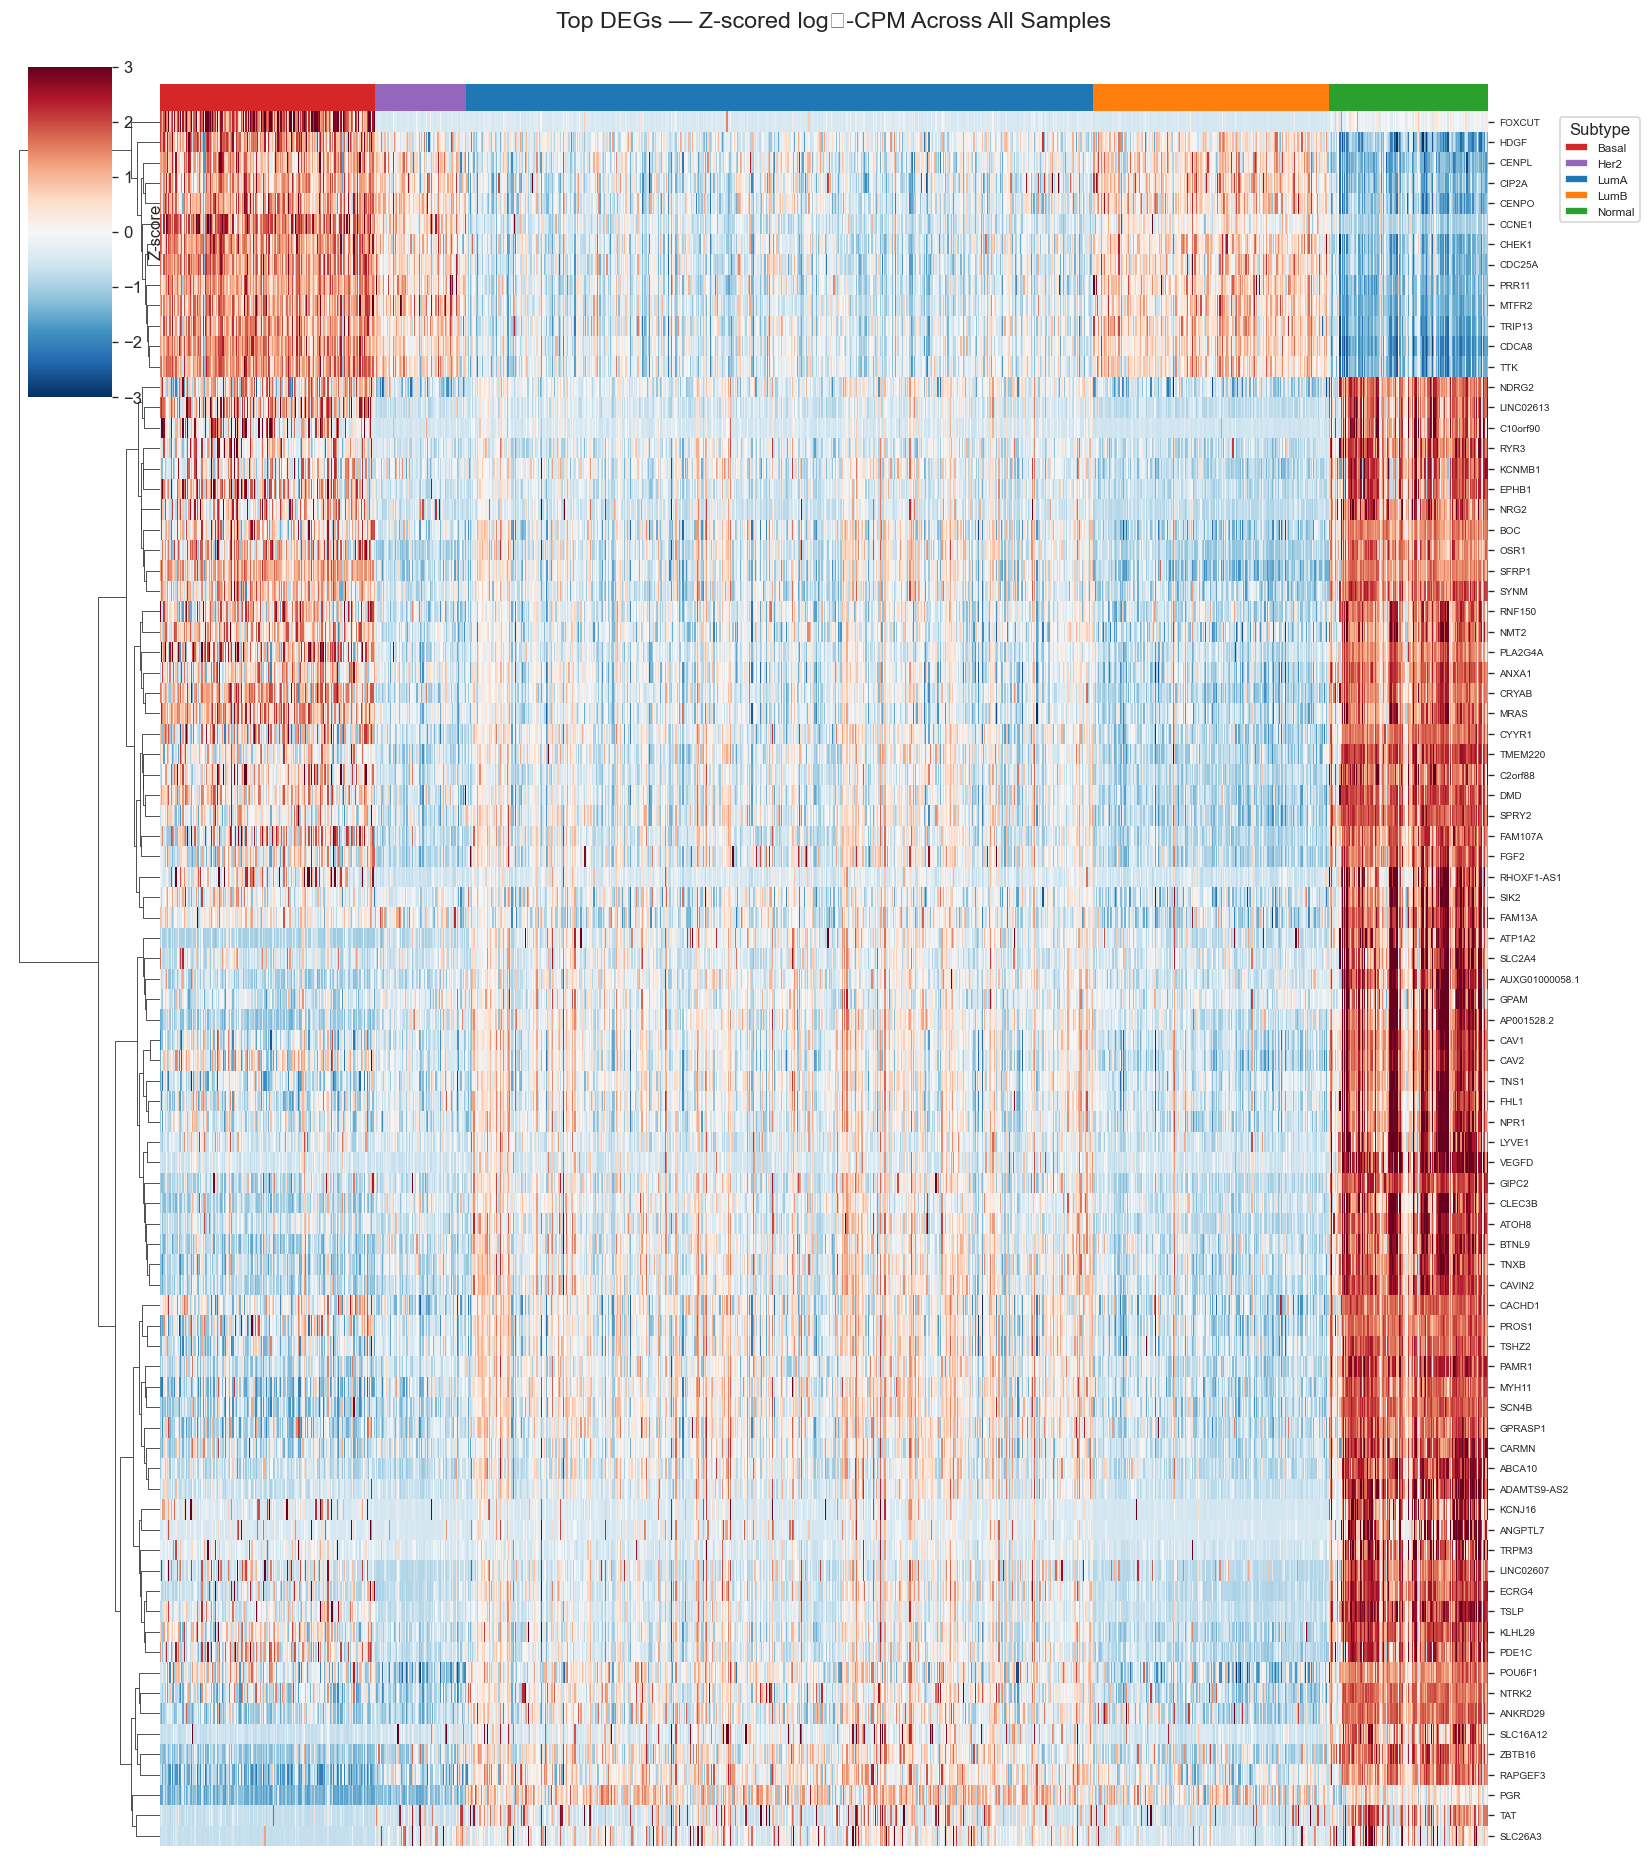

In [14]:
# Collect top 25 significant DEGs per subtype
top_genes_set = set()
for subtype in tumor_subtypes:
    sig = deg_results[subtype][deg_results[subtype]["significant"]].sort_values("padj")
    top_genes_set.update(sig.head(25).index)

top_genes = sorted(top_genes_set)
print(f"Union of top DEGs: {len(top_genes)} genes")

# Z-score normalized log2-CPM for heatmap
heatmap_data = log2_cpm.loc[log2_cpm.index.isin(top_genes), sorted_ids]
heatmap_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

col_colors = sorted_meta["subtype"].map(SUBTYPE_COLORS)

g = sns.clustermap(
    heatmap_z, col_cluster=False, row_cluster=True, method="ward",
    cmap="RdBu_r", vmin=-3, vmax=3, figsize=(14, max(8, len(top_genes) * 0.18)),
    col_colors=col_colors.values, xticklabels=False,
    yticklabels=True, cbar_kws={"label": "Z-score"},
    dendrogram_ratio=(0.1, 0.02), colors_ratio=0.015,
)
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.tick_params(axis="y", labelsize=6)
g.fig.suptitle("Top DEGs — Z-scored log₂-CPM Across All Samples", y=1.01, fontsize=14)
legend_handles = [Patch(facecolor=SUBTYPE_COLORS[s], label=s) for s in SUBTYPE_ORDER]
g.ax_heatmap.legend(handles=legend_handles, title="Subtype", loc="upper left",
                    bbox_to_anchor=(1.05, 1.0), frameon=True, fontsize=7)
plt.savefig("figures/top_degs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Subtype-Specific vs Shared DEGs (UpSet-style summary)

In [15]:
# Venn-style summary: how many DEGs are unique to each subtype vs shared?
deg_sets = {}
for subtype in tumor_subtypes:
    deg_sets[subtype] = set(deg_results[subtype][deg_results[subtype]["significant"]].index)

# Build membership matrix
all_degs = sorted(set.union(*deg_sets.values()))
membership = pd.DataFrame(
    {st: [g in deg_sets[st] for g in all_degs] for st in tumor_subtypes},
    index=all_degs
)

# Count genes unique to each subtype and shared across all
for st in tumor_subtypes:
    unique = membership[membership[st] & ~membership.drop(columns=st).any(axis=1)]
    print(f"{st}-specific DEGs: {len(unique)}")

shared_all = membership[membership.all(axis=1)]
print(f"\nShared across ALL 4 subtypes: {len(shared_all)}")
print(f"Total unique DEGs (union): {len(all_degs)}")

# Save full DEG results (all genes, not just significant) for Phase 3
for subtype in tumor_subtypes:
    deg_results[subtype].to_csv(f"results/DESeq2_full_{subtype}_vs_Normal.csv")
print("\nFull DESeq2 results saved to results/ directory.")

Basal-specific DEGs: 2477
Her2-specific DEGs: 1158
LumA-specific DEGs: 286
LumB-specific DEGs: 963

Shared across ALL 4 subtypes: 1561
Total unique DEGs (union): 11536

Full DESeq2 results saved to results/ directory.


---
## Phase 3 — Functional Enrichment and Pathway Analysis

This phase is split into two independent analyses to match the project proposal:
- GO Biological Process enrichment (only GO BP)
- KEGG pathway enrichment (only KEGG)

Then we visualize subtype-specific KEGG pathway gene expression using Biopython's KEGG API and matplotlib.

In [49]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Install/import enrichment package
try:
    import gseapy as gp
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gseapy"])
    import gseapy as gp

os.makedirs("results/phase3", exist_ok=True)
os.makedirs("figures", exist_ok=True)

tumor_subtypes = ["Basal", "Her2", "LumA", "LumB"]

# Load significant DEG tables and full DESeq2 result tables
sig_deg = {}
full_deg = {}
for subtype in tumor_subtypes:
    sig_deg[subtype] = pd.read_csv(f"results/DEGs_{subtype}_vs_Normal.csv")
    full_df = pd.read_csv(f"results/DESeq2_full_{subtype}_vs_Normal.csv")
    if "gene_name" in full_df.columns:
        full_df = full_df.set_index("gene_name")
    full_deg[subtype] = full_df

# DEG sets for enrichment (proposal: each subtype DEG set)
deg_gene_sets = {
    subtype: sorted(sig_deg[subtype]["gene_name"].dropna().astype(str).unique().tolist())
    for subtype in tumor_subtypes
}

for subtype in tumor_subtypes:
    print(f"{subtype}: {len(deg_gene_sets[subtype]):,} genes in DEG set")

Basal: 6,494 genes in DEG set
Her2: 6,248 genes in DEG set
LumA: 4,441 genes in DEG set
LumB: 6,553 genes in DEG set


### 3.1 GO Biological Process Enrichment (Only GO BP)

Run Enrichr using only `GO_Biological_Process_2023` for each subtype DEG set.

In [50]:

go_results = []

for subtype in tumor_subtypes:
    df_sig = sig_deg[subtype].copy()

    up_genes = df_sig.loc[df_sig["log2FoldChange"] > 0, "gene_name"].dropna().astype(str).unique().tolist()
    down_genes = df_sig.loc[df_sig["log2FoldChange"] < 0, "gene_name"].dropna().astype(str).unique().tolist()

    for direction, genes in [("Activated", up_genes), ("Suppressed", down_genes)]:
        if len(genes) < 10:
            print(f"Skipping {subtype} {direction}: too few genes for GO BP ({len(genes)}).")
            continue

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=["GO_Biological_Process_2023"],
            organism="human",
            outdir=None,
            cutoff=0.5,
        )

        df = enr.results.copy()
        df["Subtype"] = subtype
        df["Direction"] = direction
        # Normalise column names: gseapy may return Overlap or Genes depending on version
        if "Overlap" not in df.columns and "Genes" in df.columns:
            df["Overlap"] = df["Genes"].astype(str).apply(lambda x: str(len(x.split(";")) if x else 0) + "/0")
        # Use the p-value column that actually has values
        if df["Adjusted P-value"].isna().all() and "Old adjusted P-value" in df.columns:
            df["Adjusted P-value"] = df["Old adjusted P-value"]
            df["P-value"] = df["Old P-value"]
        df = df.sort_values("Adjusted P-value", ascending=True)
        df.to_csv(f"results/phase3/go_bp_{subtype}_{direction.lower()}.csv", index=False)
        go_results.append(df)

go_all = pd.concat(go_results, ignore_index=True) if go_results else pd.DataFrame()
if not go_all.empty:
    go_all.to_csv("results/phase3/go_bp_all_subtypes.csv", index=False)
    print(f"Saved GO BP enrichment: {go_all.shape[0]:,} rows total")
else:
    print("No GO BP enrichment results generated.")


Saved GO BP enrichment: 26,187 rows total


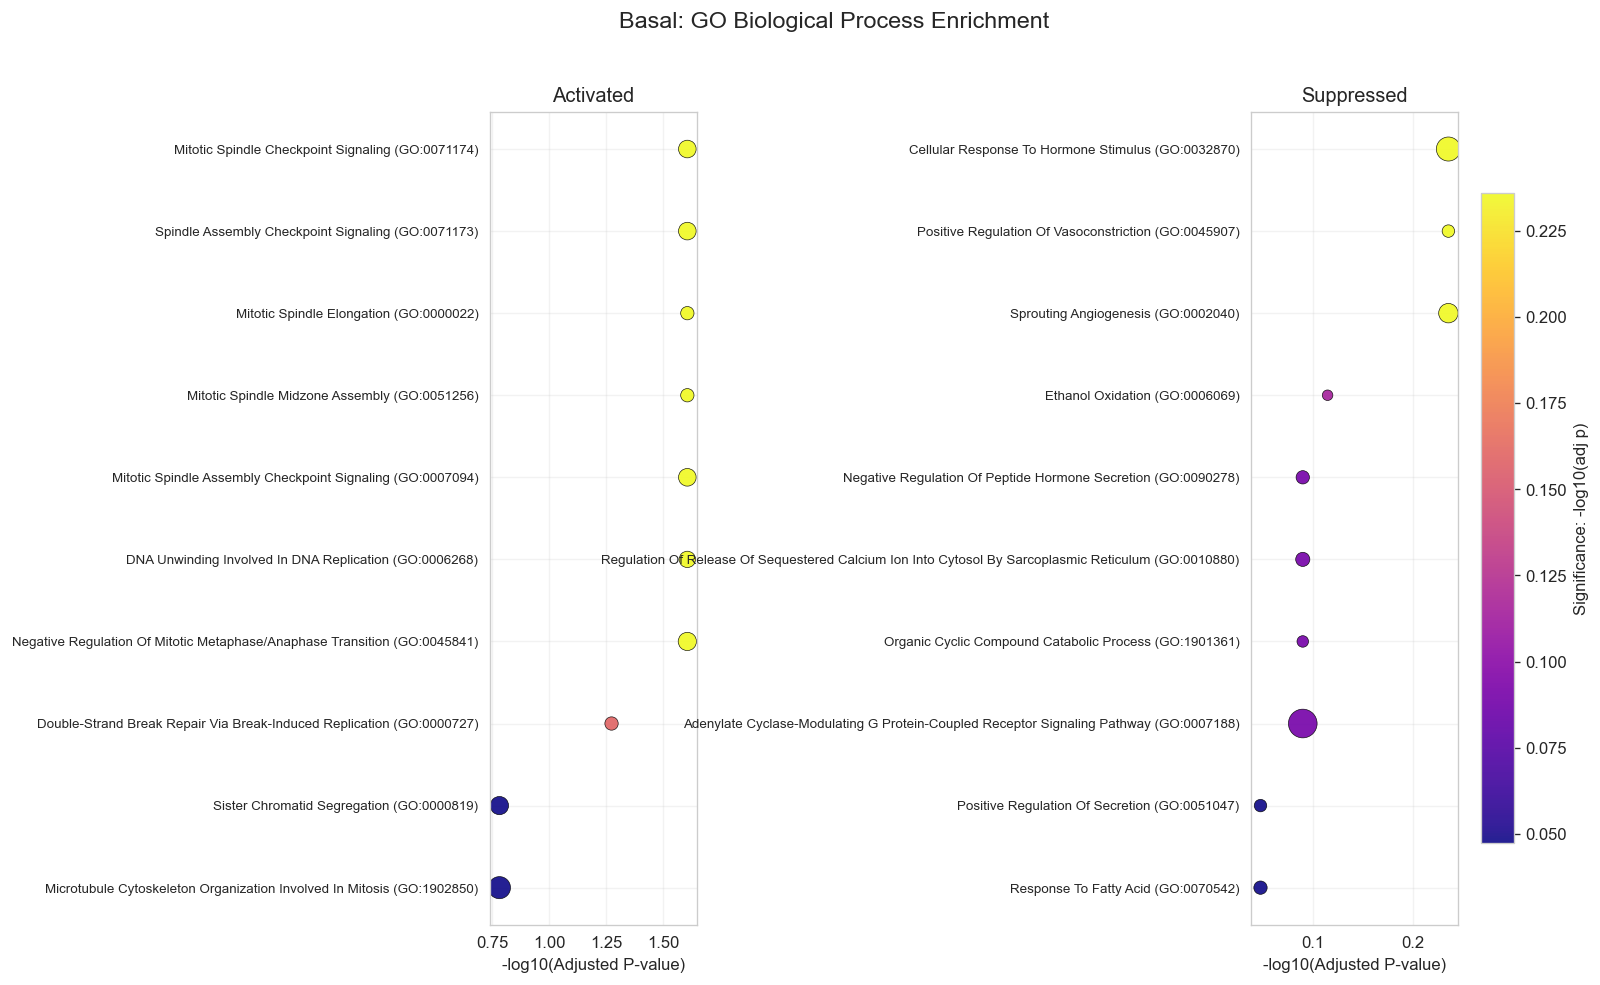

Saved GO BP dot plot: figures/phase3_go_bp_Basal_dot.png


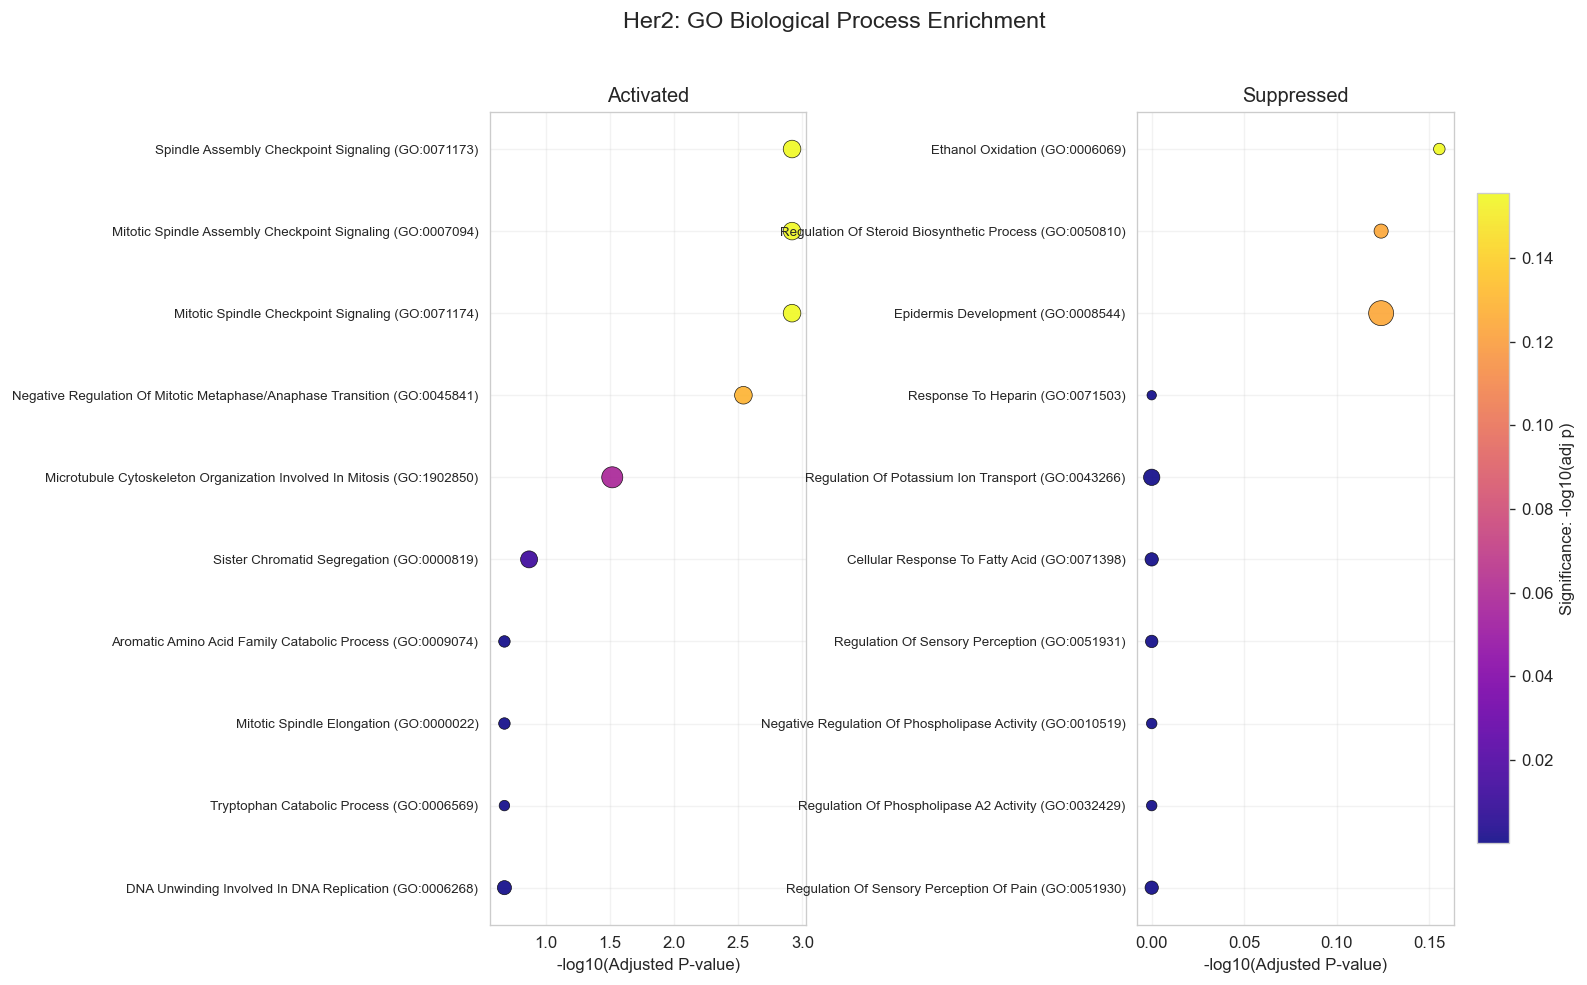

Saved GO BP dot plot: figures/phase3_go_bp_Her2_dot.png


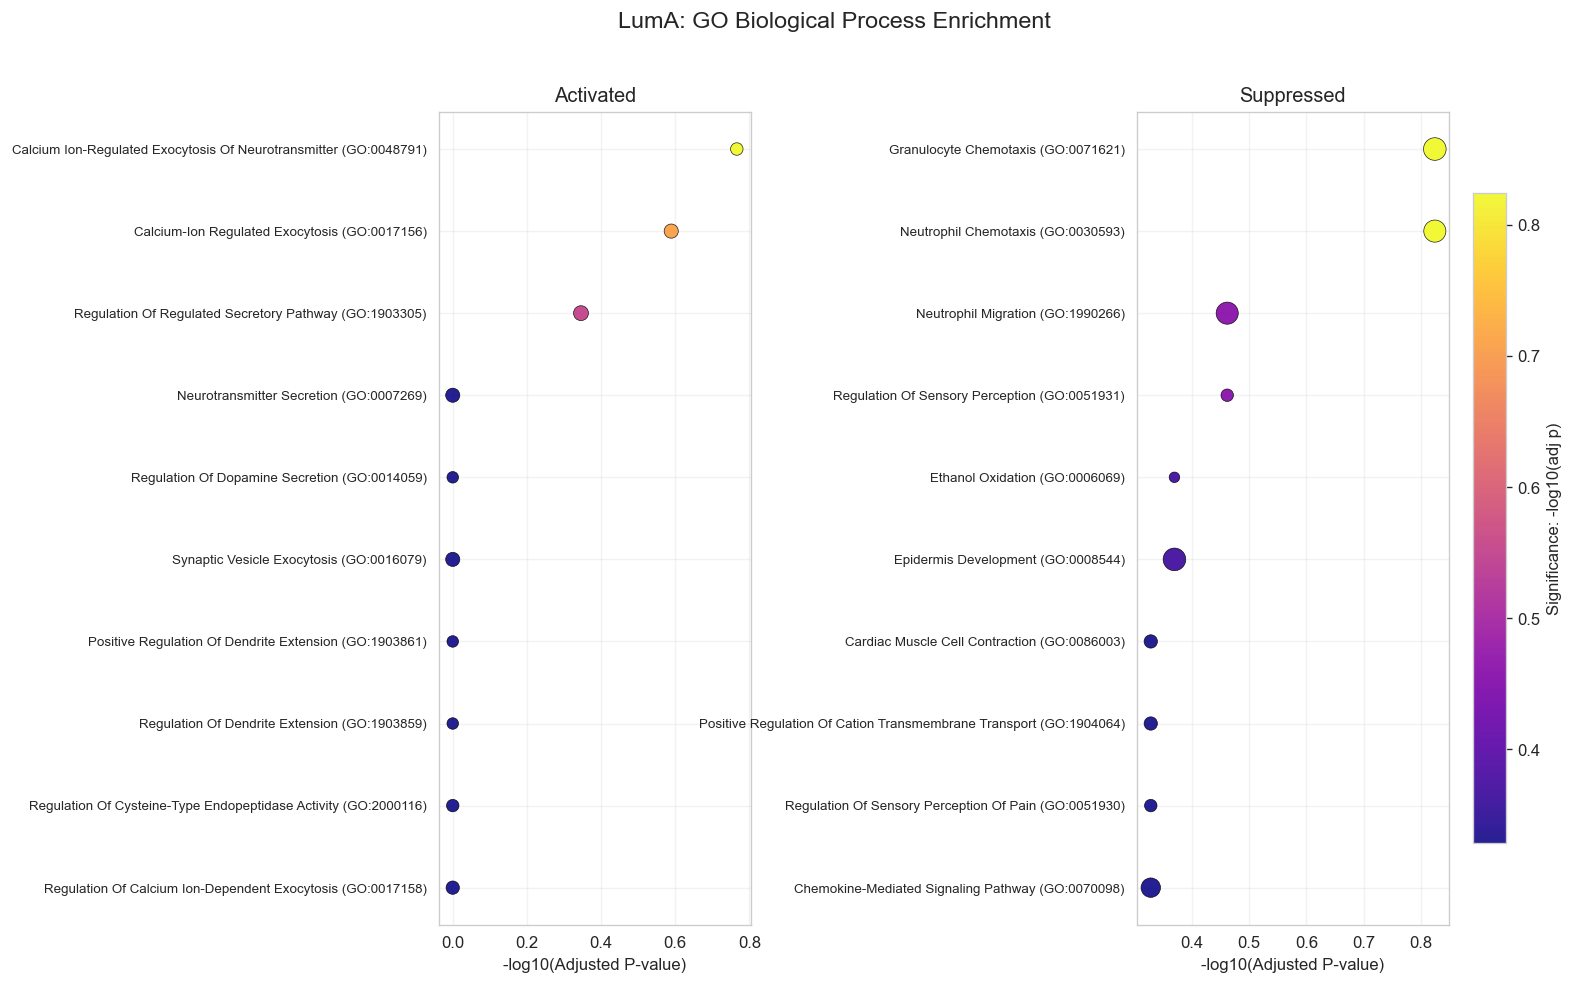

Saved GO BP dot plot: figures/phase3_go_bp_LumA_dot.png


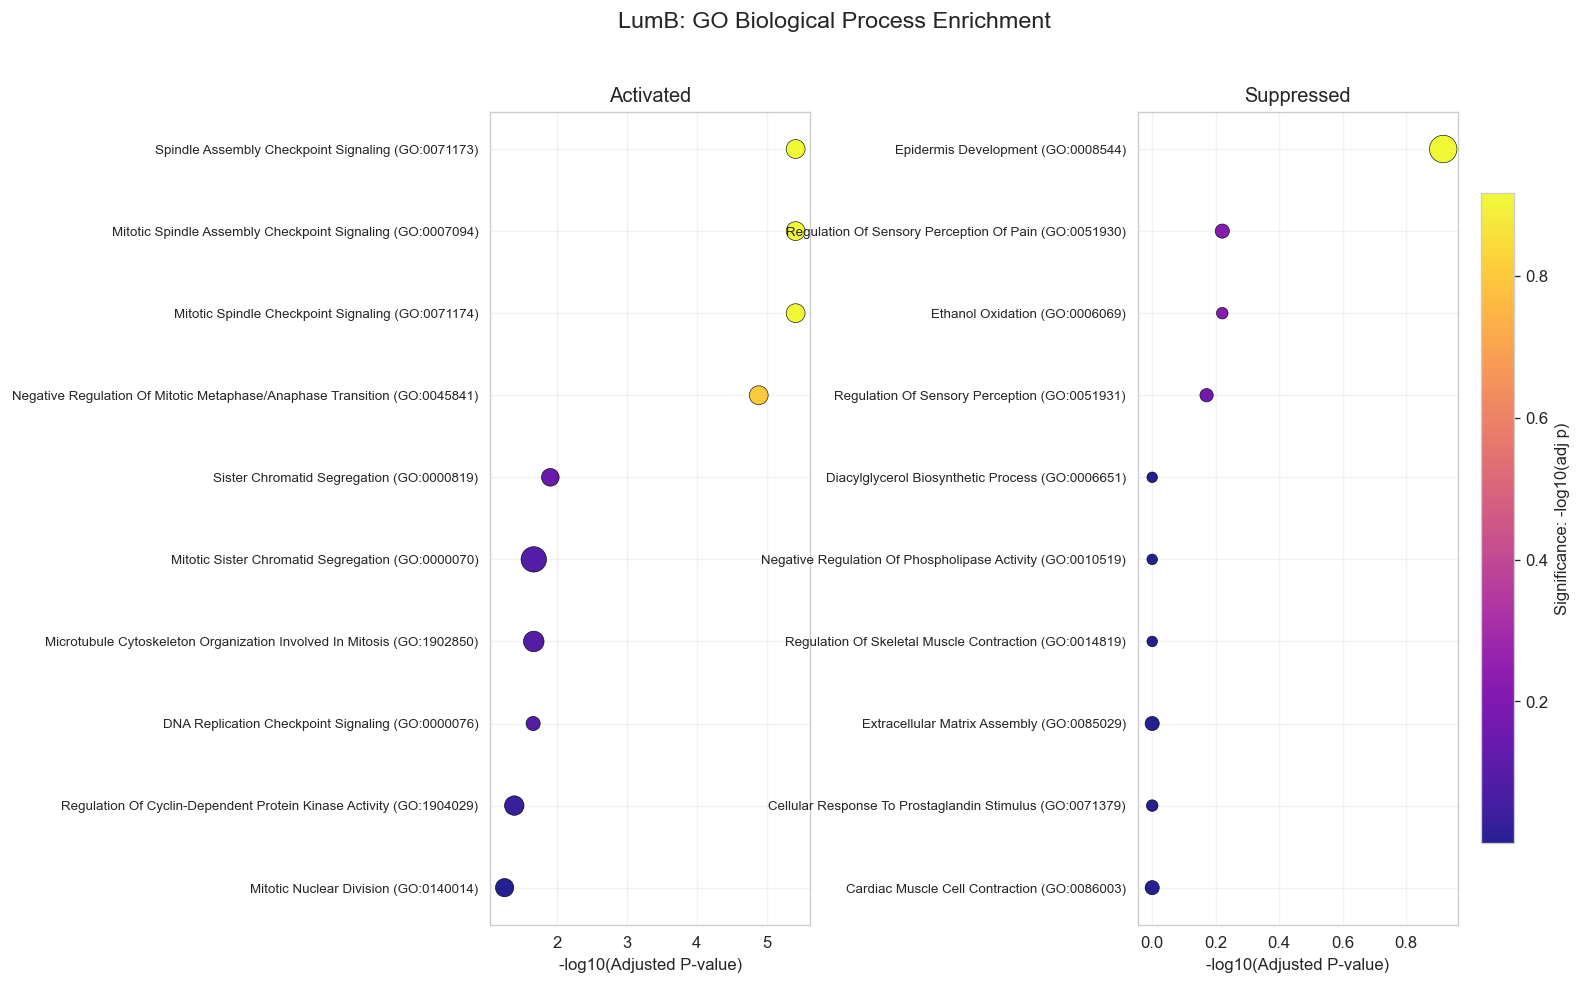

Saved GO BP dot plot: figures/phase3_go_bp_LumB_dot.png


In [51]:
if go_all.empty:
    print("No GO BP results to plot.")
else:
    for subtype in tumor_subtypes:
        sub_df = go_all[go_all["Subtype"] == subtype].copy()
        if sub_df.empty:
            print(f"Skipping {subtype}: no GO BP terms available.")
            continue

        # Parse overlap count (e.g., '23/512') to drive dot size
        sub_df["Count"] = sub_df["Overlap"].astype(str).str.split("/").str[0].astype(float)
        sub_df["neg_log10_padj"] = -np.log10(sub_df["Adjusted P-value"].clip(lower=1e-300))

        act = (sub_df[sub_df["Direction"] == "Activated"]
               .sort_values("Adjusted P-value", ascending=True)
               .head(10)
               .copy())
        sup = (sub_df[sub_df["Direction"] == "Suppressed"]
               .sort_values("Adjusted P-value", ascending=True)
               .head(10)
               .copy())

        if act.empty and sup.empty:
            print(f"Skipping {subtype}: no activated/suppressed GO terms available.")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)
        panels = [(axes[0], act, "Activated"), (axes[1], sup, "Suppressed")]
        scat = None

        for ax, dfp, label in panels:
            if dfp.empty:
                ax.set_title(label)
                ax.text(0.5, 0.5, "No terms", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue

            dfp = dfp.sort_values("neg_log10_padj", ascending=True)
            y = np.arange(len(dfp))
            scat = ax.scatter(
                dfp["neg_log10_padj"],
                y,
                s=dfp["Count"] * 8,
                c=dfp["neg_log10_padj"],
                cmap="plasma",
                alpha=0.9,
                edgecolor="black",
                linewidth=0.4,
            )
            ax.set_yticks(y)
            ax.set_yticklabels(dfp["Term"], fontsize=8)
            ax.set_xlabel("-log10(Adjusted P-value)")
            ax.set_title(label)
            ax.grid(alpha=0.25)

        fig.suptitle(f"{subtype}: GO Biological Process Enrichment", y=1.02, fontsize=14)
        fig.tight_layout()

        if scat is not None:
            cbar = fig.colorbar(scat, ax=axes, shrink=0.8, pad=0.02)
            cbar.set_label("Significance: -log10(adj p)")

        out_path = f"figures/phase3_go_bp_{subtype}_dot.png"
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved GO BP dot plot: {out_path}")